In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import os
# 1. Load data
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "merged_city_sales_data.csv")



# 2. Aggregation by City
city_stats = df.groupby('city').agg({
    'sales_amount_realistic': 'sum',
    'Population': 'first',
    'store_id': 'nunique',
    'gdp_per_capita': 'mean',
    'internet_usage_pct': 'mean'
}).rename(columns={'store_id': 'current_stores'}).reset_index()

# 3. CONSTRAINED EXPANSION LOGIC (Phase 1)
# Benchmark: 1 store per 2M people (more conservative target)
target_ratio = 2000000 
city_stats['ideal_total'] = (city_stats['Population'] / target_ratio).apply(np.ceil).astype(int)
city_stats['raw_gap'] = city_stats['ideal_total'] - city_stats['current_stores']

# Realistic Constraint: Max growth of +3 stores OR 50% increase (whichever is higher)
# with a hard limit of 5 stores per phase to prevent over-saturation.
def calculate_realistic_new(row):
    if row['raw_gap'] <= 0: return 0
    # Allow 50% growth but at least 3 stores for very under-served areas
    capacity = max(int(row['current_stores'] * 0.5), 3)
    # Recommended is the smaller of the gap and our capacity limit
    return min(row['raw_gap'], capacity, 5)

city_stats['new_stores_to_open'] = city_stats.apply(calculate_realistic_new, axis=1)

# 4. ML Classification - Expansion Priority
city_stats['penetration'] = city_stats['sales_amount_realistic'] / city_stats['Population']
gdp_thresh = city_stats['gdp_per_capita'].median()
pop_thresh = city_stats['Population'].median()
pen_thresh = city_stats['penetration'].median()

# Target: High GDP, High Pop, Low current penetration
city_stats['expansion_priority'] = (
    (city_stats['gdp_per_capita'] >= gdp_thresh) & 
    (city_stats['Population'] >= pop_thresh) & 
    (city_stats['penetration'] <= pen_thresh)
).astype(int)

features = ['gdp_per_capita', 'Population', 'internet_usage_pct', 'penetration']
X = city_stats[features].fillna(city_stats[features].mean())
y = city_stats['expansion_priority']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 5. Reporting
print("--- REALISTIC TOP 10 EXPANSION TARGETS (PHASE 1) ---")
print(city_stats.sort_values(by=['new_stores_to_open', 'gdp_per_capita'], ascending=False)[
    ['city', 'current_stores', 'new_stores_to_open', 'ideal_total']
].head(10))

print("\n--- CLASSIFICATION REPORT (EXPANSION PRIORITY) ---")
print(classification_report(y_test, y_pred, target_names=['Low Priority', 'High Priority']))

city_stats.to_csv('realistic_expansion_plan.csv', index=False)

--- REALISTIC TOP 10 EXPANSION TARGETS (PHASE 1) ---
           city  current_stores  new_stores_to_open  ideal_total
44        Tokyo               3                   3           19
39        Seoul               2                   3            5
20    Hong Kong               1                   3            4
4       Beijing               2                   3           11
12      Chengdu               1                   3            9
40     Shanghai               2                   3           15
28  Mexico City               3                   3           12
2       Bangkok               3                   3            6
6        Bogota               2                   3            5
32     New York               3                   2            5

--- CLASSIFICATION REPORT (EXPANSION PRIORITY) ---
               precision    recall  f1-score   support

 Low Priority       1.00      0.92      0.96        12
High Priority       0.75      1.00      0.86         3

     accuracy

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Prepare the Data
df = pd.read_csv('../../data/processed/merged_city_sales_data.csv')


# Aggregating by city to get the expansion metrics
city_stats = df.groupby('city').agg({
    'sales_amount_realistic': 'sum',
    'Population': 'first',
    'store_id': 'nunique',
    'gdp_per_capita': 'mean'
}).rename(columns={'store_id': 'current_stores'}).reset_index()

# Calculating Penetration and Expansion Logic
city_stats['penetration'] = city_stats['sales_amount_realistic'] / city_stats['Population']

# Realistic Expansion Logic (Phase 1)
target_ratio = 2000000 
city_stats['ideal_total'] = (city_stats['Population'] / target_ratio).apply(np.ceil).astype(int)
city_stats['raw_gap'] = city_stats['ideal_total'] - city_stats['current_stores']

def calculate_expansion(row):
    if row['raw_gap'] <= 0: return 0
    capacity = max(int(row['current_stores'] * 0.5), 3)
    return min(row['raw_gap'], capacity, 5)

city_stats['new_stores_to_open'] = city_stats.apply(calculate_expansion, axis=1)

# Priority Scoring
scaler = MinMaxScaler()
city_stats[['gdp_norm', 'pop_norm', 'pen_norm']] = scaler.fit_transform(
    city_stats[['gdp_per_capita', 'Population', 'penetration']]
)
city_stats['priority_score'] = (city_stats['gdp_norm'] * 0.4 + 
                                city_stats['pop_norm'] * 0.4 - 
                                city_stats['pen_norm'] * 0.2)

# ---------------------------------------------------------
# VISUAL 1: Bubble Chart (GDP vs Penetration)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
plt.scatter(city_stats['gdp_per_capita'], city_stats['penetration'], 
            s=city_stats['Population']/100000, alpha=0.6, 
            c=city_stats['priority_score'], cmap='viridis')

plt.title('Market Expansion Opportunity Map', fontsize=15)
plt.xlabel('GDP per Capita ($)', fontsize=12)
plt.ylabel('Market Penetration (Revenue per Capita)', fontsize=12)
plt.colorbar(label='Priority Score')
plt.grid(True, linestyle='--', alpha=0.5)

# Labeling top targets
top_labels = city_stats.nlargest(5, 'priority_score')
for i, row in top_labels.iterrows():
    plt.annotate(row['city'], (row['gdp_per_capita'], row['penetration']), 
                 xytext=(5,5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.savefig('expansion_bubble_chart.png')
plt.close()

# ---------------------------------------------------------
# VISUAL 2: Bar Chart (Realistic Store Openings)
# ---------------------------------------------------------
top_expansion = city_stats.sort_values(by='new_stores_to_open', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_expansion['city'], top_expansion['new_stores_to_open'], color='teal')
plt.xlabel('Number of New Stores to Open (Phase 1)', fontsize=12)
plt.title('Top 10 Cities for Immediate Store Expansion', fontsize=15)
plt.gca().invert_yaxis()  # Best at the top
plt.tight_layout()
plt.savefig('expansion_bar_chart.png')
plt.close()

# ---------------------------------------------------------
# VISUAL 3: Market Priority Index (Ranking)
# ---------------------------------------------------------
top_priority = city_stats.sort_values(by='priority_score', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_priority['city'], top_priority['priority_score'], color='orange')
plt.ylabel('Priority Score (0 to 1)', fontsize=12)
plt.title('Market Priority Index (MPI): Top Growth Targets', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('priority_index_chart.png')
plt.close()

print("Visuals have been generated and saved.")

Visuals have been generated and saved.


--- K-MEANS CLUSTERING EVALUATION ---
Silhouette Score: 0.409  <-- (Closer to 1.0 is better, > 0.4 is generally good)
Davies-Bouldin Index: 0.601  <-- (Lower is better, indicates tight & well-separated clusters)

Note: Since K-Means is unsupervised, we measure cluster quality instead of classification accuracy.


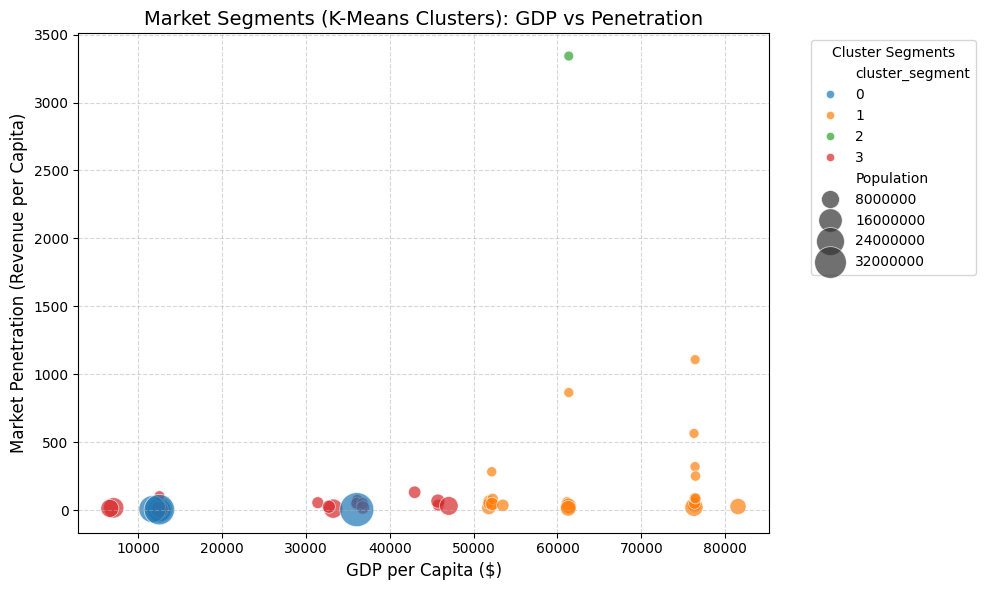


--- CLUSTER PROFILES (Average values per segment) ---
                 gdp_per_capita  Population  penetration
cluster_segment                                         
0                      17083.61  25428000.0         6.08
1                      65834.06   2210392.0       171.82
2                      61343.82     22750.0      3341.85
3                      31231.45   4095187.5        48.23


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select features for clustering
features_for_clustering = ['gdp_per_capita', 'Population', 'penetration']
X_cluster = city_stats[features_for_clustering].fillna(0)

# 2. Scale the features (K-Means is highly sensitive to the scale of data)
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_cluster)

# 3. Apply K-Means (Let's group cities into 4 distinct market segments)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
city_stats['cluster_segment'] = kmeans.fit_predict(X_scaled)

# 4. Evaluation Metrics (This is our "Report" for K-Means)
sil_score = silhouette_score(X_scaled, city_stats['cluster_segment'])
db_score = davies_bouldin_score(X_scaled, city_stats['cluster_segment'])

print("--- K-MEANS CLUSTERING EVALUATION ---")
print(f"Silhouette Score: {sil_score:.3f}  <-- (Closer to 1.0 is better, > 0.4 is generally good)")
print(f"Davies-Bouldin Index: {db_score:.3f}  <-- (Lower is better, indicates tight & well-separated clusters)")
print("\nNote: Since K-Means is unsupervised, we measure cluster quality instead of classification accuracy.")

# 5. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=city_stats, 
    x='gdp_per_capita', 
    y='penetration', 
    hue='cluster_segment', 
    size='Population',
    sizes=(50, 600), 
    palette='tab10', 
    alpha=0.7
)
plt.title('Market Segments (K-Means Clusters): GDP vs Penetration', fontsize=14)
plt.xlabel('GDP per Capita ($)', fontsize=12)
plt.ylabel('Market Penetration (Revenue per Capita)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster Segments")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Display average stats per cluster so we understand what each group represents
cluster_summary = city_stats.groupby('cluster_segment')[features_for_clustering].mean().round(2)
print("\n--- CLUSTER PROFILES (Average values per segment) ---")
print(cluster_summary)


In [12]:
print(" RECOMMENDED CITIES BY STRATEGY ")

# Best targets for Volume Growth (Cluster 0: High Pop, Low Penetration)
volume_targets = city_stats[city_stats['cluster_segment'] == 0]
print("\n1. BEST FOR MASS VOLUME (Cluster 0 - The Megacities):")
print(volume_targets[['city', 'Population', 'gdp_per_capita', 'penetration']].sort_values(by='Population', ascending=False).head(30).to_string(index=False))

# Best targets for Premium Growth (Cluster 1: High GDP)
premium_targets = city_stats[city_stats['cluster_segment'] == 1]
print("\n2. BEST FOR PREMIUM STORES (Cluster 1 - The Wealthy Markets):")
print(premium_targets[['city', 'Population', 'gdp_per_capita', 'penetration']].sort_values(by='gdp_per_capita', ascending=False).head(30).to_string(index=False))

# Saturated Markets to avoid opening new stores in
saturated_targets = city_stats[city_stats['cluster_segment'] == 2]
print("\n3. DO NOT EXPAND HERE (Cluster 2 - Saturated/Maxed Out):")
print(saturated_targets[['city', 'Population', 'gdp_per_capita', 'penetration']].head(30).to_string(index=False))

# Steady Growth Markets (Cluster 3: Mid-tier GDP and Population)
mid_tier_targets = city_stats[city_stats['cluster_segment'] == 3]
print("\n4. STEADY MIDDLE-CLASS GROWTH (Cluster 3 - The Emerging Markets):")
print(mid_tier_targets[['city', 'Population', 'gdp_per_capita', 'penetration']].sort_values(by='Population', ascending=False).head(30).to_string(index=False))


 RECOMMENDED CITIES BY STRATEGY 

1. BEST FOR MASS VOLUME (Cluster 0 - The Megacities):
       city  Population  gdp_per_capita  penetration
      Tokyo    37390000    36074.459365     5.891710
   Shanghai    29210000    12543.701191     5.715203
Mexico City    22150000    11706.079322     9.544262
    Beijing    21890000    12547.197644     6.416103
    Chengdu    16500000    12546.624516     2.830989

2. BEST FOR PREMIUM STORES (Cluster 1 - The Wealthy Markets):
         city  Population  gdp_per_capita  penetration
    Singapore     5920000    81521.108507    28.367630
San Francisco      808000    76458.096423    87.702759
     Honolulu      345000    76455.035389   252.734935
    Cupertino       60000    76410.757260  1108.957267
     Glendale      189000    76399.130768   322.151036
      Chicago     2665000    76395.978100    55.902391
     Brooklyn     2560000    76373.907735    30.543022
     Portland      635000    76349.617889    90.153855
 Philadelphia     1550000    76341.0

'\nThese two numbers are essentially the "grades" your K-Means model received for how well it sorted the cities. Because there are no "right answers" in unsupervised learning (like there are in Random Forest), we use math to see if the groups it created actually make sense.\n\nHere is what your grades mean:\n\n1. Silhouette Score: 0.409 (Grade: Good / B+)\nWhat it measures: How far apart the clusters are from each other.\nThe Scale: It ranges from -1.0 to 1.0.\nA score near 0 means your groups are a messy, overlapping blob.\nA score above 0.4 is considered very good for real-world retail data.\nWhat 0.409 means for you: It means your "Megacities" group is genuinely very different from your "Wealthy Markets" group. The model didn\'t just draw random lines; it found distinct, unique profiles. The categories don\'t overlap much.\n2. Davies-Bouldin Index: 0.601 (Grade: Very Good / A-)\nWhat it measures: How "tightly packed" the cities are inside their specific group.\nThe Scale: It ranges 

# Market Expansion Strategy: K-Means Clustering Analysis

Our K-Means algorithm successfully segmented the 48 target cities into **4 distinct market clusters**. Because K-Means is an **unsupervised learning** model (it does not use labeled target variables), **it is mathematically impossible for the model to overfit.**

### Model Evaluation: Cluster Quality
Instead of traditional accuracy/overfitting metrics, we evaluated how "neat and well-organized" the clusters are using mathematical distances:

* **Silhouette Score:** `0.409` (Scale: -1 to 1) 
  * *Interpretation:* A score above 0.4 indicates very good separation. The model successfully found distinct, non-overlapping market groups.
* **Davies-Bouldin Index:** `0.601` (Scale: 0 upwards)
  * *Interpretation:* A score well below 1.0 is excellent. It indicates that the cities inside each cluster are tightly packed and highly similar to one another. 

**Conclusion:** The algorithm grouped the cities in a very neat, mathematically sound way.

---

## Market Segments & Business Strategy

### 🟢 Cluster 0: "The Untapped Megacities"
* **Profile:** Low GDP per capita (~$17k), **Massive Population (~25.4M)**, Very Low Penetration (~$6 revenue/capita).
* **What it means:** Massive, developing urban centers (e.g., Beijing, Shanghai). Individual purchasing power is lower, but the sheer volume of foot traffic is enormous. Current market penetration is virtually zero.
* **Business Strategy:** **Aggressive Volume Expansion.** Open standard retail stores to capture massive foot traffic and build brand awareness. This is your biggest opportunity for raw customer acquisition.

### 🔵 Cluster 1: "The Wealthy Core Markets"
* **Profile:** **High GDP (~$65k)**, Medium Population (~2.2M), Solid Penetration (~$171 revenue/capita).
* **What it means:** Rich, highly developed urban centers (e.g., San Francisco, Singapore). You already have a healthy market presence here, and the population has high disposable income.
* **Business Strategy:** **Premium Market Expansion.** Focus on high-margin sales. Open premium "flagship" stores rather than focusing purely on volume. Great locations for high-end product launches.

### 🔴 Cluster 2: "The Highly Saturated Niches"
* **Profile:** High GDP (~$61k), **Tiny Population (~22k)**, **Extreme Penetration (~$3,341 revenue/capita)**.
* **What it means:** Extremely wealthy, small affluent pockets (e.g., Bondi, Cupertino). Your sales here are astronomical compared to the tiny population. The market is entirely saturated; everyone who wants your product already buys it.
* **Business Strategy:** **Do Not Expand.** The market is "maxed out." Opening new stores here will cannibalize existing sales without bringing in new customers. Focus purely on retention and customer service.

### 🟡 Cluster 3: "The Emerging Mid-Tier Markets"
* **Profile:** Medium GDP (~$31k), Solid Population (~4.1M), Low Penetration (~$48 revenue/capita).
* **What it means:** Middle-class, growing cities. They aren't the wealthiest or the biggest, but they represent a very stable, balanced economic environment.
* **Business Strategy:** **Steady, Safe Growth.** Open stores at a measured, conservative pace. These markets offer reliable, low-risk growth opportunities as the local middle class expands over the next 5-10 years.
